## Week 3: 2D Molecular Dynamics Engine & Langevin Thermostat

### A slightly more sophisticated version of the verlet integrator implemented in the previous task that is 2D & can calculate for temperature

##### Input: Initial positons and velocities of atoms AND potential energy (atom-atom interactions)
##### Output: Series of snapshot positions and velocities (MD trajectory/movie)

In [1]:
#libraries

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import random

In [2]:
#Code from Project 2

def VerletMDEngine(initial_pos, initial_vel, potential_e, snapshots=50, m=1, dt_step = 0.001):

    time = np.arange(snapshots, dtype=float) * dt_step 

    energy = np.zeros(snapshots, dtype=float)

    x_step = np.zeros(snapshots, dtype=float) ; v_step = np.zeros(snapshots, dtype=float) ; force = np.zeros(snapshots, dtype=float)

    x = float(initial_pos) ; v = float(initial_vel) ; v_halfstep = float(initial_vel)

    k = float(potential_e) 

    


    for i in range(snapshots):

        F = -k * x
        force[i] = F 
        v_halfstep = v + ((1/(2*m)) * F * dt_step) 

        x_next = x + (v_halfstep * dt_step)
        x_step[i] = x_next

        F_step = -k * x_next

        v_next = v_halfstep + ((1/(2*m)) * F_step * dt_step) 
        v_step[i] = v_next

        pe = 0.5 * k * np.power(x_next, 2)
        ke = 0.5 * m * np.power(v_next, 2)

        energy[i] = pe + ke

        x = x_next ; v = v_next



    return time, x_step, v_step, energy

x_i = 2.0 ; v_i = 0 ; k = 1.0 ; snapshots = 5000 ; m=1

omega = np.sqrt(k/m)

#### Task 1: Extend Verlet Simulation to 2D

##### Set function to account for 2D particle movement and "Vectorize" the function. Then plot x(t), y(t) and Vx(t), Vy(t)

x -> x̲

y -> y̲

F -> F̲

In [5]:
#random.seed(2)

def VerletMDEngine_2d(initial_pos, initial_vel, kx=1, ky=1, snapshots=50, m=1, dt_step = 0.001):

    time = np.arange(snapshots, dtype=float) * dt_step 

    energy = np.zeros(snapshots, dtype=float)

    #x_step = np.zeros(snapshots, dtype=float) ; v_step = np.zeros(snapshots, dtype=float)

    x_2d = np.zeros((snapshots, 2), dtype=float) ; v_2d = np.zeros((snapshots, 2), dtype=float)
    force_2d = np.zeros((snapshots,2), dtype=float)

    x = np.array(initial_pos) ; v = np.array(initial_vel)
    #v_halfstep = float(initial_vel)

    #k = float(potential_e) 

    x_2d[0] = np.array(initial_pos, dtype=float)
    v_2d[0] = np.array(initial_vel, dtype=float)

    k_2d = np.array([kx, ky], dtype=float) 
    
    F = -k_2d * x

    x_2d[0] = x ; v_2d[0] = v ; force_2d[0] = F
    pe_0 = 0.5 * k_2d * np.power(x, 2)
    ke_0 = 0.5 * m * np.power(v, 2)
    energy[0] = pe_0.sum() + ke_0.sum()


    for i in range(1, snapshots): #vectorized
        
        v_halfstep = v + ((1/(2*m)) * F * dt_step) 
        x_next = x + (v_halfstep * dt_step)
        f_next = -k_2d * x_next
        v_next = v_halfstep + ((1/(2*m)) * f_next * dt_step) 

        x_2d[i] = x_next
        v_2d[i] = v_next
        force_2d[i] = f_next


        pe = 0.5 * k_2d * np.power(x_next, 2)
        ke = 0.5 * m * np.power(v_next, 2)

        energy[i] = pe.sum() + ke.sum()

        x = x_next ; v = v_next ; F = f_next



    return time, x_2d, v_2d, energy


In [6]:
kx = 2.0 ; ky = 1.0 ; snapshots = 5000 ; m=1 ; dt=0.01

omega = np.sqrt(kx/m)
timestep = dt*omega

pos_1 = [0.0,1.0] ; vel_1 = [0.5,1.0] #Initial position and velocity values 

# ^^ To set parameters ^^



omega = np.sqrt(kx/m)

time, x, v, energy = VerletMDEngine_2d(pos_1, vel_1, kx, ky, snapshots=50, m=1, dt_step = timestep)

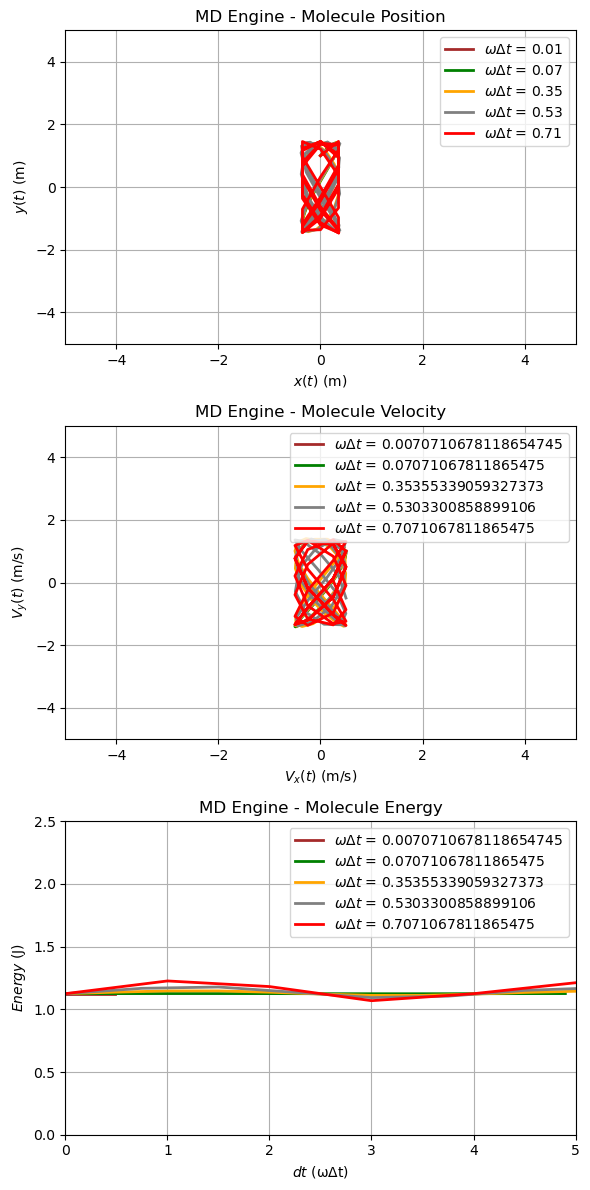

<Figure size 640x480 with 0 Axes>

In [10]:
random.seed(5)

fig, (ax, av, ae) = plt.subplots(3,1, figsize=(6,12))
color_list = ['red', 'blue', 'green', 'orange', 'brown', 'gray']
timescale = [0.01, 0.1, 0.5, 0.75, 1.0]

for t in timescale:
    dt = t/omega

    selected_color = random.choice(color_list)
    color_list.remove(selected_color)

    time, x, v, energy = VerletMDEngine_2d(pos_1, vel_1, kx, ky, snapshots=50, m=1, dt_step = dt)
    ax.plot(x[:,0], x[:,1], color = selected_color, linestyle = "-", linewidth=2, label = f"$ωΔt$ = {dt:0.2f}")
    av.plot(v[:,0], v[:,1], color = selected_color, linestyle = "-", linewidth=2, label = "$ωΔt$ = " + str(dt))
    ae.plot(time*omega, energy, color = selected_color, linestyle = "-", linewidth=2, label = "$ωΔt$ = " + str(dt))



ax.set_xlabel('$x(t)$ (m)') ; ax.set_ylabel('$y(t)$ (m)') 
ax.set_xlim(-5, 5) ; ax.set_ylim(-5, 5)
ax.legend(loc="upper right") ; ax.set_title("MD Engine - Molecule Position") ; ax.grid(True) ; 

av.set_xlabel('$V_x(t)$ (m/s)') ; av.set_ylabel('$V_y(t)$ (m/s)') 
av.set_xlim(-5, 5) ; av.set_ylim(-5, 5)
av.legend(loc="upper right") ; av.set_title("MD Engine - Molecule Velocity") ; av.grid(True) ; 

ae.set_xlabel('$dt$ (ωΔt)') ; ae.set_ylabel('$Energy$ (J)') 
ae.set_xlim(0, 5) ; ae.set_ylim(0, 2.5)
ae.legend(loc="upper right") ; ae.set_title("MD Engine - Molecule Energy") ; ae.grid(True) ; 


plt.tight_layout()

plt.show()
plt.savefig("MD_Engine_Stats.pdf")

#### Task 1.5: Animate (x(t), y(t))

##### Animate the movement of the 2D verlet function

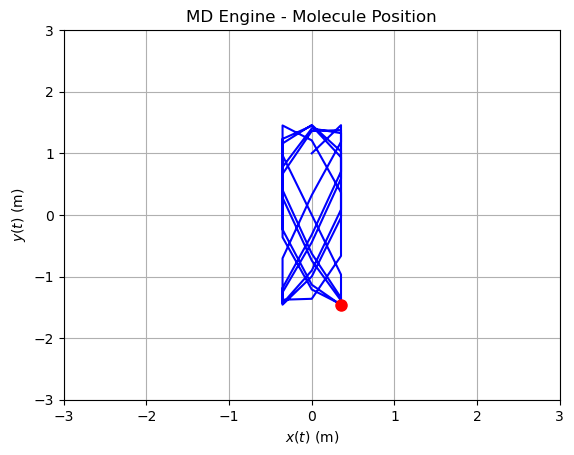

In [11]:
fig, axis = plt.subplots()

axis.set_xlabel('$x(t)$ (m)') ; axis.set_ylabel('$y(t)$ (m)') 
axis.set_xlim(-3, 3) ; axis.set_ylim(-3, 3)
axis.set_title("MD Engine - Molecule Position") ; axis.grid(True)

ani_line, = axis.plot([], [], 'b-')  #line tracked
ani_point, = axis.plot([], [], 'ro', markersize=8)  #position point

def init(): #New Function
    ani_line.set_data([], [])
    ani_point.set_data([], [])
    return ani_line, ani_point


def update_data(frame):
    
    if frame > 0:
        x_coord = x[:frame+1,0]
        y_coord = x[:frame+1,1]
        ani_line.set_data(x_coord, y_coord)
        ani_point.set_data([x[frame,0]], [x[frame,1]])  #Current 2D point

    return ani_line, ani_point



frame_count = min(1000, len(x)) #Frame cap: if x>1000, it returns 1000
animation = FuncAnimation(fig=fig, func=update_data, frames=frame_count, init_func=init, interval=200, blit=True, repeat=True)

HTML(animation.to_jshtml())

#----------------------------------------------------------------------------------

animation.save("animation.gif", writer = 'pillow', fps=15) #Added pillow writer 

#### Task 2: Thermostat (Langevin)

##### Plot T(t) for your simulation

In [17]:
def VerletMDEngine_2d(initial_pos, initial_vel, kx=1, ky=1, snapshots=50, m=1, dt_step = 0.001):

    time = np.arange(snapshots, dtype=float) * dt_step 

    energy = np.zeros(snapshots, dtype=float)

    #x_step = np.zeros(snapshots, dtype=float) ; v_step = np.zeros(snapshots, dtype=float)

    x_2d = np.zeros((snapshots, 2), dtype=float) ; v_2d = np.zeros((snapshots, 2), dtype=float)
    force_2d = np.zeros((snapshots,2), dtype=float)

    x = np.array(initial_pos) ; v = np.array(initial_vel) ; ke_list = np.zeros(snapshots, dtype=float)
    #v_halfstep = float(initial_vel)

    #k = float(potential_e) 

    x_2d[0] = np.array(initial_pos, dtype=float)
    v_2d[0] = np.array(initial_vel, dtype=float)

    k_2d = np.array([kx, ky], dtype=float) 
    
    F = -k_2d * x

    x_2d[0] = x ; v_2d[0] = v ; force_2d[0] = F
    pe_0 = 0.5 * k_2d * np.power(x, 2)
    ke_0 = 0.5 * m * np.power(v, 2)
    energy[0] = pe_0.sum() + ke_0.sum()
    ke_list[0] = ke_0.sum()

    #--------------------- New stuff
    particles = 1
    boltzmann = 1 #1.380649e-23 
    gamma = 0.1 #friction
    target_temp = 1.0
    sigma = np.sqrt(2 * gamma * boltzmann * target_temp / m) #
    force_random = np.sqrt(dt_step) * sigma * np.random.normal(size=2)
    rand = np.random.default_rng()



    for i in range(1, snapshots): #vectorized

        #random_number = rand.normal(size=2) didnt need
        force_random = np.sqrt(dt_step) * sigma * np.random.normal(size=2)
        
        #v_halfstep = v + ((1/(2*m)) * F * dt_step)
        
        v_halfstep = v + (((F/m) - gamma * v) * (dt_step/2)) + force_random/2 #New equation for halfstep
        x_next = x + (v_halfstep * dt_step)
        f_next = -k_2d * x_next
        v_next = v_halfstep + + (((f_next / m) - gamma * v_halfstep) * (dt_step / 2.0)) + 0.5 * force_random #still working on

        x_2d[i] = x_next
        v_2d[i] = v_next
        force_2d[i] = f_next


        pe = 0.5 * k_2d * np.power(x_next, 2)
        ke = 0.5 * m * np.power(v_next, 2)
        ke_list[i] = ke.sum()

        energy[i] = pe.sum() + ke.sum()

        x = x_next ; v = v_next ; F = f_next


    
    temperature = np.zeros(v_2d.size, dtype=float)
    dimensions = v_2d.shape[1]

    temperature = (ke_list * 2) / (boltzmann * dimensions * particles)



    return time, x_2d, v_2d, energy, temperature


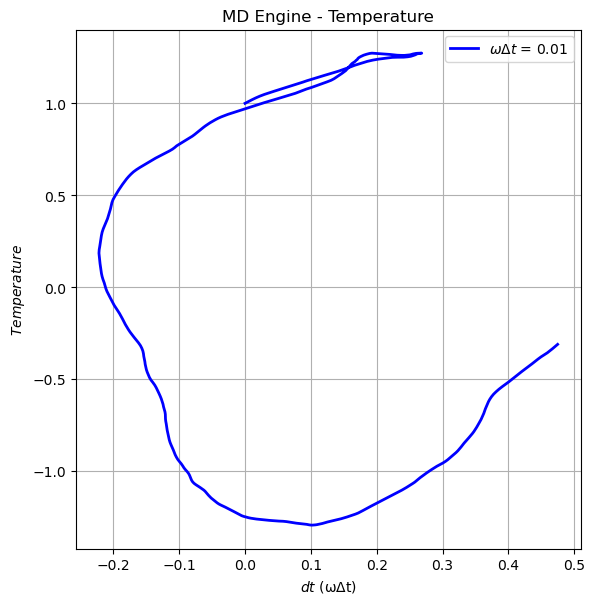

In [18]:
pos_1 = [0.0,1.0] ; vel_1 = [0.5,1.0] ; kx = 1.0 ; ky = 1.0 ; m=1 ; 

# ^^ To set parameters ^^

dt=0.01
omega = np.sqrt(kx/m)
timestep = dt*omega

time = 5.0
snapshots = int(time / timestep)

time, x, v, energy, temp = VerletMDEngine_2d(pos_1, vel_1, kx=1, ky=1, snapshots = snapshots, m=1, dt_step = timestep)

plt.figure(figsize=(6,6))

plt.xlabel('$dt$ (ωΔt)') ; plt.ylabel('$Temperature$') 

#plt.xlim(0, 5) ; plt.ylim(0, 1200)



plt.tight_layout()
plt.plot(x[:,0], x[:,1], "b-", linewidth=2, label = '$ωΔt$ = ' + str(dt))
plt.legend(loc="upper right") ; plt.title("MD Engine - Temperature") ; plt.grid(True) ;  plt.show()

In [ ]:
pos_1 = [0.0,1.0] ; vel_1 = [0.5,1.0] ; kx = 1.0 ; ky = 1.0 ; m=1 ; 

# ^^ To set parameters ^^

dt=0.01
omega = np.sqrt(kx/m)
timestep = dt*omega

time = 5.0
snapshots = int(time / timestep)

time, x, v, energy, temp = VerletMDEngine_2d(pos_1, vel_1, kx=1, ky=1, snapshots = snapshots, m=1, dt_step = timestep)

fig2, axis = plt.subplots(figsize=(6,6))

axis.set_xlabel('$dt$ (ωΔt)') ; axis.set_ylabel('$Temperature$') 

axis.set_xlim(0, 5) ; axis.set_ylim(0, 1200)



plt.tight_layout()
axis.plot(time, temp, "b-", linewidth=2, label = '$ωΔt$ = ' + str(dt))
axis.set_title("MD Engine - Temperature") ; axis.grid(True)

#-------------------------------------

ani_line, = axis.plot([], [], 'b-')  #line tracked
ani_point, = axis.plot([], [], 'ro', markersize=8)  #position point

def init(): #New Function
    ani_line.set_data([], [])
    ani_point.set_data([], [])
    return ani_line, ani_point

def update_data(frame):
    
    if frame > 0:
        ani_line.set_data(time[:frame], temp[:frame])  # updates the line with current data
        ani_point.set_data([time[frame-1]], [temp[frame-1]])  # current point
    return ani_line, ani_point


frame_count = min(1000, len(x))

animation = FuncAnimation(fig=fig2, func=update_data, frames=frame_count, init_func=init, interval=50, blit=True, repeat=True) 

HTML(animation.to_jshtml()) 

#----------------------------------------------------------------------------------

animation.save("temperature.gif", writer = 'pillow', fps=15)

Animation size has reached 20982469 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


In [ ]:
#old code

'''
def md_thermostat(velocity, mass, kinetic_e):
    boltzmann = 1.380649e-23 
    temperature = np.zeros(velocity.size, dtype=float)
    particles, dimensions = velocity.shape

    temperature = kinetic_e * 2 / (boltzmann * dimensions * particles)

    for t in kinetic_e:
        temperature[t] = kinetic_e[t] * 2 / (boltzmann * dimensions * particles)

    return temperature
    '''

'\ndef md_thermostat(velocity, mass, kinetic_e):\n    boltzmann = 1.380649e-23 \n    temperature = np.zeros(velocity.size, dtype=float)\n    particles, dimensions = velocity.shape\n\n    temperature = kinetic_e * 2 / (boltzmann * dimensions * particles)\n\n    for t in kinetic_e:\n        temperature[t] = kinetic_e[t] * 2 / (boltzmann * dimensions * particles)\n\n    return temperature\n    '